In [32]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

In [33]:
dataset_path_train = r'DATASET\TRAIN'
dataset_path_test = r'DATASET\TEST'

In [34]:
train_images = tf.keras.utils.image_dataset_from_directory(
    dataset_path_train,
    seed = 123,
    image_size = (224,224),
    color_mode = 'rgb',
    batch_size = 32,
    label_mode = 'int'
)


Found 22564 files belonging to 2 classes.


In [35]:
test_images = tf.keras.utils.image_dataset_from_directory(
    dataset_path_test,
    seed = 123,
    image_size = (224, 224),
    color_mode = 'rgb',
    batch_size = 32,
    label_mode = 'int'
)

Found 2513 files belonging to 2 classes.


In [36]:
# Defining the CNN model
model = models.Sequential()

In [38]:
model = models.Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Conv2D(32, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation = 'sigmoid')

])



In [39]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [40]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,265 (19.48 MB)

 Trainable params: 5,107,265 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    train_images,
    validation_data = test_images,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 227s 320ms/step - accuracy: 0.7972 - loss: 2.2627 - val_accuracy: 0.8691 - val_loss: 0.3662
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 243s 344ms/step - accuracy: 0.8372 - loss: 0.3879 - val_accuracy: 0.8583 - val_loss: 0.3808
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 237s 336ms/step - accuracy: 0.8474 - loss: 0.3631 - val_accuracy: 0.8949 - val_loss: 0.2861
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 281s 398ms/step - accuracy: 0.8643 - loss: 0.3355 - val_accuracy: 0.8758 - val_loss: 0.3228
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 645s 912ms/step - accuracy: 0.8701 - loss: 0.3239 - val_accuracy: 0.8993 - val_loss: 0.2621
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 435s 617ms/step - accuracy: 0.8762 - loss: 0.3059 - val_accuracy: 0.8747 - val_loss: 0.3628
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 285s 404ms/step - accuracy: 0.8890 - loss: 0.2793 - val_accuracy: 0.8977 - val_loss: 0.3218
Epoch 8/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 247s 350ms/step - accuracy: 0.8976 -

In [44]:
# Initialize empty lists
y_true = []
y_pred = []

# Loop through the test dataset
for images, labels in test_images:
    # 1. Get the model's raw probability output (a float between 0 and 1)
    preds = model.predict(images)
    
    # 2. Apply thresholding: 
    # If probability > 0.5, class is 1, else 0.
    binary_preds = (preds > 0.5).astype("int32")
    
    # 3. Store the results
    y_true.extend(labels.numpy())
    y_pred.extend(binary_preds.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━

In [46]:
# Add this print statement before your confusion_matrix code
print(f"Unique values in predictions: {np.unique(y_pred)}")

Unique values in predictions: [0 1]


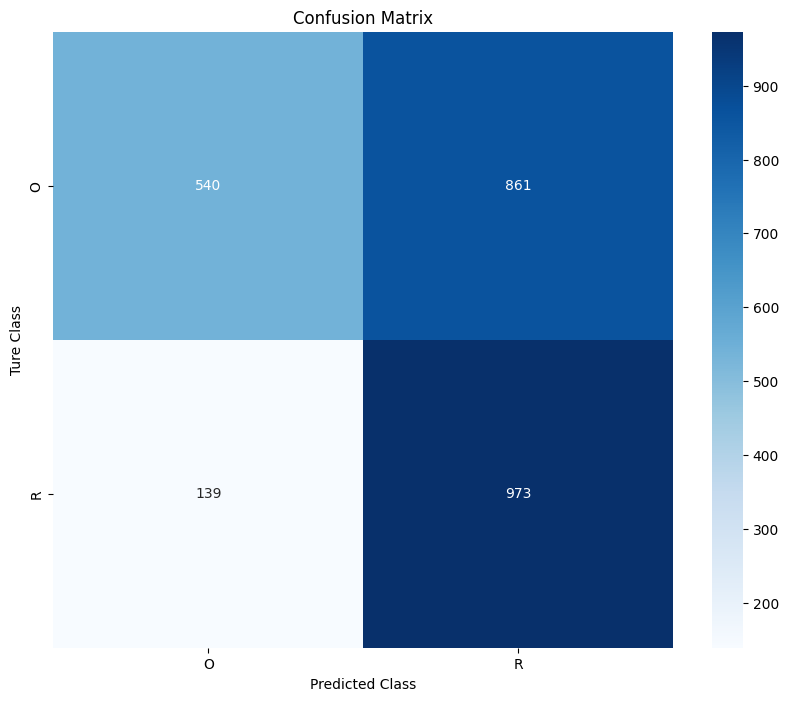

In [47]:
# Creating the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

class_names = test_images.class_names

plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Ture Class')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_true, y_pred), target_name = class_names)

              precision    recall  f1-score   support

           0       0.80      0.39      0.52      1401
           1       0.53      0.88      0.66      1112

    accuracy                           0.60      2513
   macro avg       0.66      0.63      0.59      2513
weighted avg       0.68      0.60      0.58      2513

